## Importing Required Libraries

In [1]:
# For reading, analysing and cleaning data
import pandas as pd
import numpy as np

# For plotting data
from matplotlib import pyplot as plt
import seaborn as sns

# For Feature selction and splitting data
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split

# For model training
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB

# For evaluation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

# For model Loading and Saving
import joblib

# For dynamic model
from kafka import KafkaConsumer
from kafka import KafkaProducer
from datetime import datetime
from json import dumps, loads
from tqdm import tqdm

In [2]:
# reading dataset
data = pd.read_csv('Kafka_dataset.csv')
data.head()

,timestamp,FQDN_count,subdomain_length,upper,lower,numeric,entropy,special,labels,labels_max,labels_average,longest_word,sld,len,subdomain,Target Attack
0,20:54.9,13,0,0,12,0,2.781301,1,2,10,6.000000,games,gamesisart,11,0,0
1,40:06.7,25,8,0,10,9,2.786216,6,6,7,3.333333,2,192,12,1,0
2,26:34.8,8,0,0,6,0,2.154135,2,2,5,3.500000,cm,cm-tv,6,0,0
3,27:12.4,20,3,0,18,0,2.905639,2,3,12,6.000000,cacao,leyaeducacao,16,1,0
4,39:19.0,27,10,0,10,11,2.767195,6,6,7,3.666667,2,192,14,1,1


In [3]:
data.shape

(268064, 16)

## Data Analysis

#### Checking number of Unique values and datatypes of each column

In [4]:
# prinintg each column's unique value and data type
for col in data.columns:
    print(f"{col} has {len(data[col].unique())} and datatype is {data[col].dtype}")

timestamp has 35936 and datatype is object
FQDN_count has 34 and datatype is int64
subdomain_length has 25 and datatype is int64
upper has 5 and datatype is int64
lower has 34 and datatype is int64
numeric has 13 and datatype is int64
entropy has 783 and datatype is float64
special has 9 and datatype is int64
labels has 7 and datatype is int64
labels_max has 31 and datatype is int64
labels_average has 76 and datatype is float64
longest_word has 9541 and datatype is object
sld has 21648 and datatype is object
len has 33 and datatype is int64
subdomain has 2 and datatype is int64
Target Attack has 2 and datatype is int64


#### Checking Imbalance data

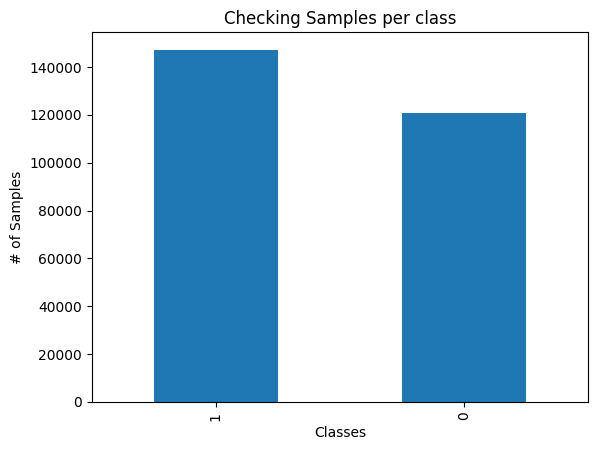

In [5]:
# take target variable and plots its unique value with frequency
data['Target Attack'].value_counts().plot(kind='bar')

plt.xlabel("Classes")
plt.ylabel("# of Samples")
plt.title("Checking Samples per class")
plt.show()

In [6]:
data['Target Attack'].value_counts() # just counting target class values

1    147174
0    120890
Name: Target Attack, dtype: int64

Since there are two classes and 'Class 1' has approx 27 thousands more sample than 'Class 0', so data is biased towards 'Class 1'.

#### Checking Skewness of Data

In [7]:
# print skewness of each feature
data.skew(axis=0, skipna = True, numeric_only=True)

FQDN_count         -1.154592
subdomain_length   -0.622994
upper               5.958372
lower               0.392060
numeric            -0.633108
entropy            -0.146507
special            -0.932878
labels             -0.951932
labels_max          4.020548
labels_average      5.089901
len                 2.649951
subdomain          -1.232448
Target Attack      -0.197053
dtype: float64

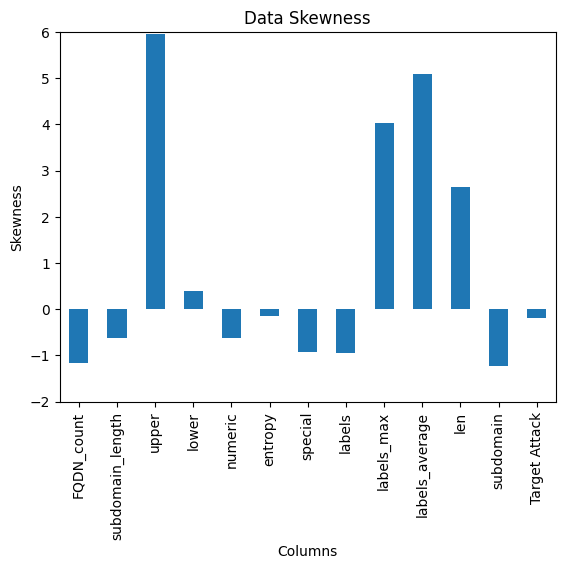

In [8]:
# ploting skewnes of each feature
data.skew(axis=0, skipna = True, numeric_only=True).plot(kind='bar')
plt.ylim((-2, 6))
plt.xlabel("Columns")
plt.ylabel("Skewness")
plt.title("Data Skewness")
plt.show()

If thhe skewness is between -0.5 and 0.5, the data are fairly distributed. If the skewness is between -1 and – 0.5 or between 0.5 and 1, the data are moderately skewed. If the skewness is less than -1 or greater than 1, the data are highly skewed.

Postive Skew Columns:
1. upper
2. labels_max
3. labels_average
4. len

Negative Skew Columns:
1. FDQN_count
2. subdomain

#### Data Distribution
Checking the data distribution of features and Target Label

In [9]:
# data discription
data.describe()

,FQDN_count,subdomain_length,upper,lower,numeric,entropy,special,labels,labels_max,labels_average,len,subdomain,Target Attack
count,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000,268064.000000
mean,22.403930,6.142246,0.853789,10.415904,6.581104,2.484318,4.553133,4.823579,8.228516,4.787701,12.597742,0.762307,0.549026
std,5.934605,3.867386,4.961201,3.244899,4.464568,0.407850,2.199056,1.790056,4.402309,4.585092,4.168610,0.425671,0.497592
min,2.000000,0.000000,0.000000,0.000000,0.000000,0.311278,0.000000,1.000000,2.000000,1.500000,2.000000,0.000000,0.000000
25%,19.000000,3.000000,0.000000,10.000000,0.000000,2.054029,2.000000,3.000000,7.000000,3.166667,11.000000,1.000000,0.000000
50%,24.000000,7.000000,0.000000,10.000000,8.000000,2.570417,6.000000,6.000000,7.000000,3.666667,12.000000,1.000000,1.000000
75%,27.000000,10.000000,0.000000,10.000000,11.000000,2.767195,6.000000,6.000000,7.000000,4.000000,14.000000,1.000000,1.000000
max,36.000000,29.000000,32.000000,34.000000,12.000000,4.368167,8.000000,7.000000,32.000000,32.000000,35.000000,1.000000,1.000000


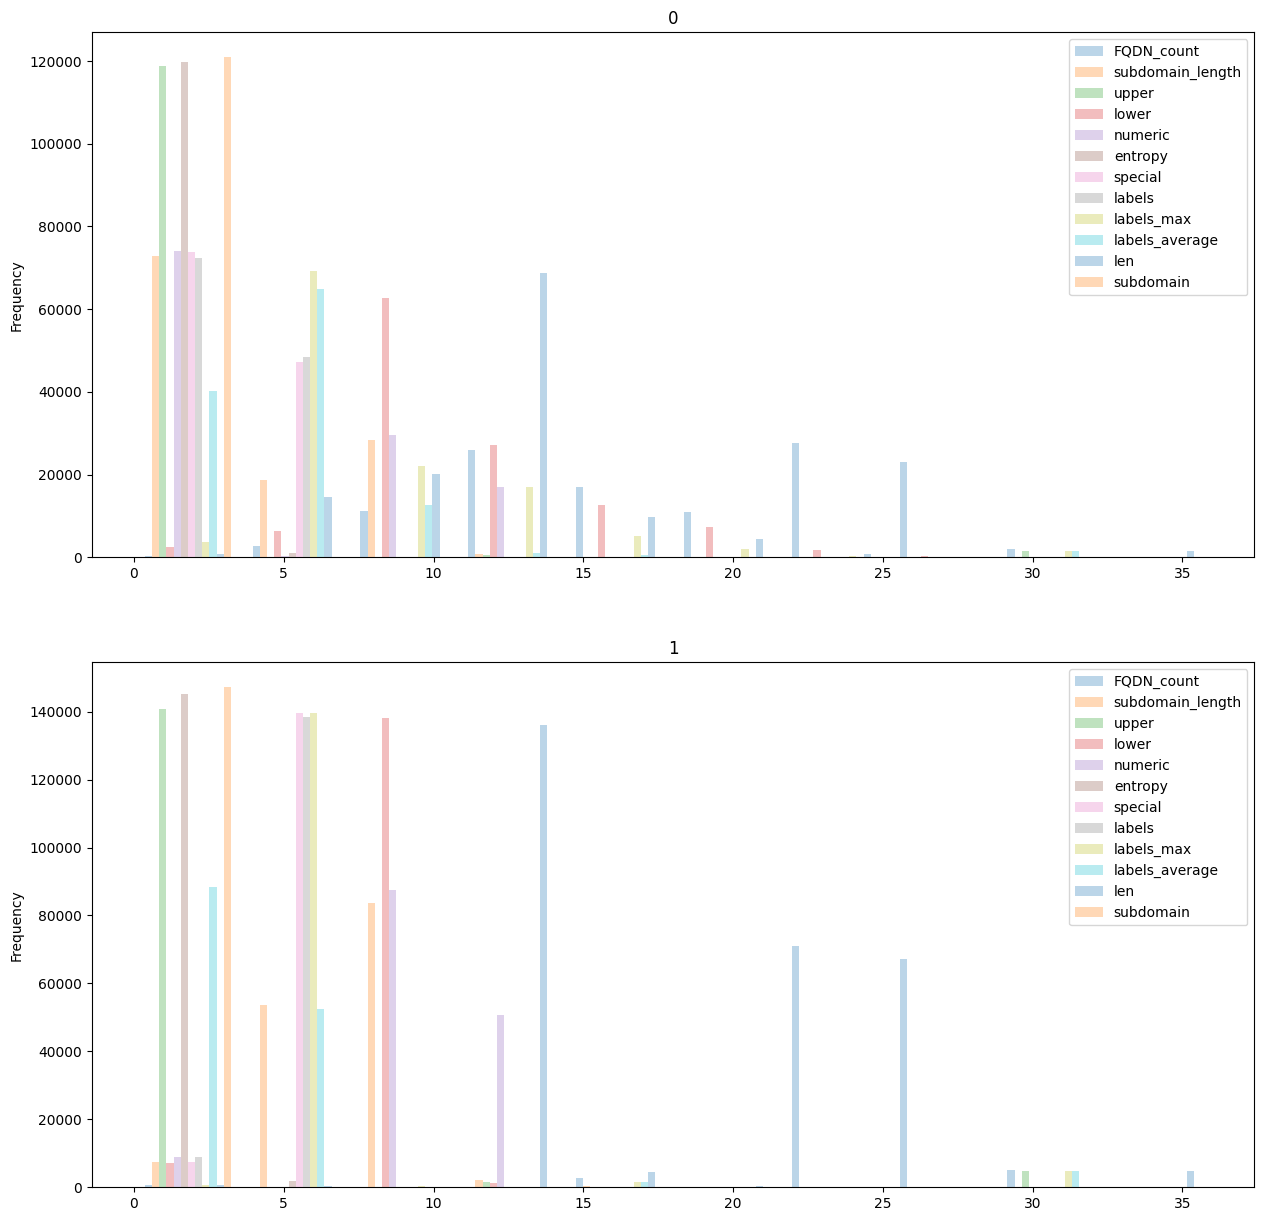

In [10]:
# ploting data distribution
data.plot.hist(by="Target Attack", figsize=(15, 15), alpha=0.3)
plt.show()

## Data Cleaning

#### Removing Null Values

In [11]:
# checking number of null values in each column
data.isna().sum()

timestamp           0
FQDN_count          0
subdomain_length    0
upper               0
lower               0
numeric             0
entropy             0
special             0
labels              0
labels_max          0
labels_average      0
longest_word        6
sld                 0
len                 0
subdomain           0
Target Attack       0
dtype: int64

Since number of null values are very less, so we can remove them without effecting data

In [12]:
# deleting rows whihc contain null value in any column
data.dropna(axis=1, inplace=True)

In [13]:
data.isna().sum()

timestamp           0
FQDN_count          0
subdomain_length    0
upper               0
lower               0
numeric             0
entropy             0
special             0
labels              0
labels_max          0
labels_average      0
sld                 0
len                 0
subdomain           0
Target Attack       0
dtype: int64

All null values has been removed

#### Converting Categorical data to Numerical
As We have seen above in datatypes of dataset, there are only 3 column which are object:
1. timestamp (it will be excluded because it does not play important role in classification)
2. sld
3. len

So checks for categorical data will be applied only to them.

In [14]:
# converting categorical data to numeircal using encoding
data['sld'] = data['sld'].astype('category').cat.codes

In [15]:
data['len'] = data['len'].astype('category').cat.codes

In [16]:
# checking data types after conversion
data.dtypes

timestamp            object
FQDN_count            int64
subdomain_length      int64
upper                 int64
lower                 int64
numeric               int64
entropy             float64
special               int64
labels                int64
labels_max            int64
labels_average      float64
sld                   int16
len                    int8
subdomain             int64
Target Attack         int64
dtype: object

Data is converted into numerical form (except timestamp which will be removed later)

## Data Selection

In [17]:
# Dropping  timestamp column, because time has not effect on data
data.drop(columns=['timestamp'], inplace=True)

#### Filter Method
Using Pearson's Corelation technique

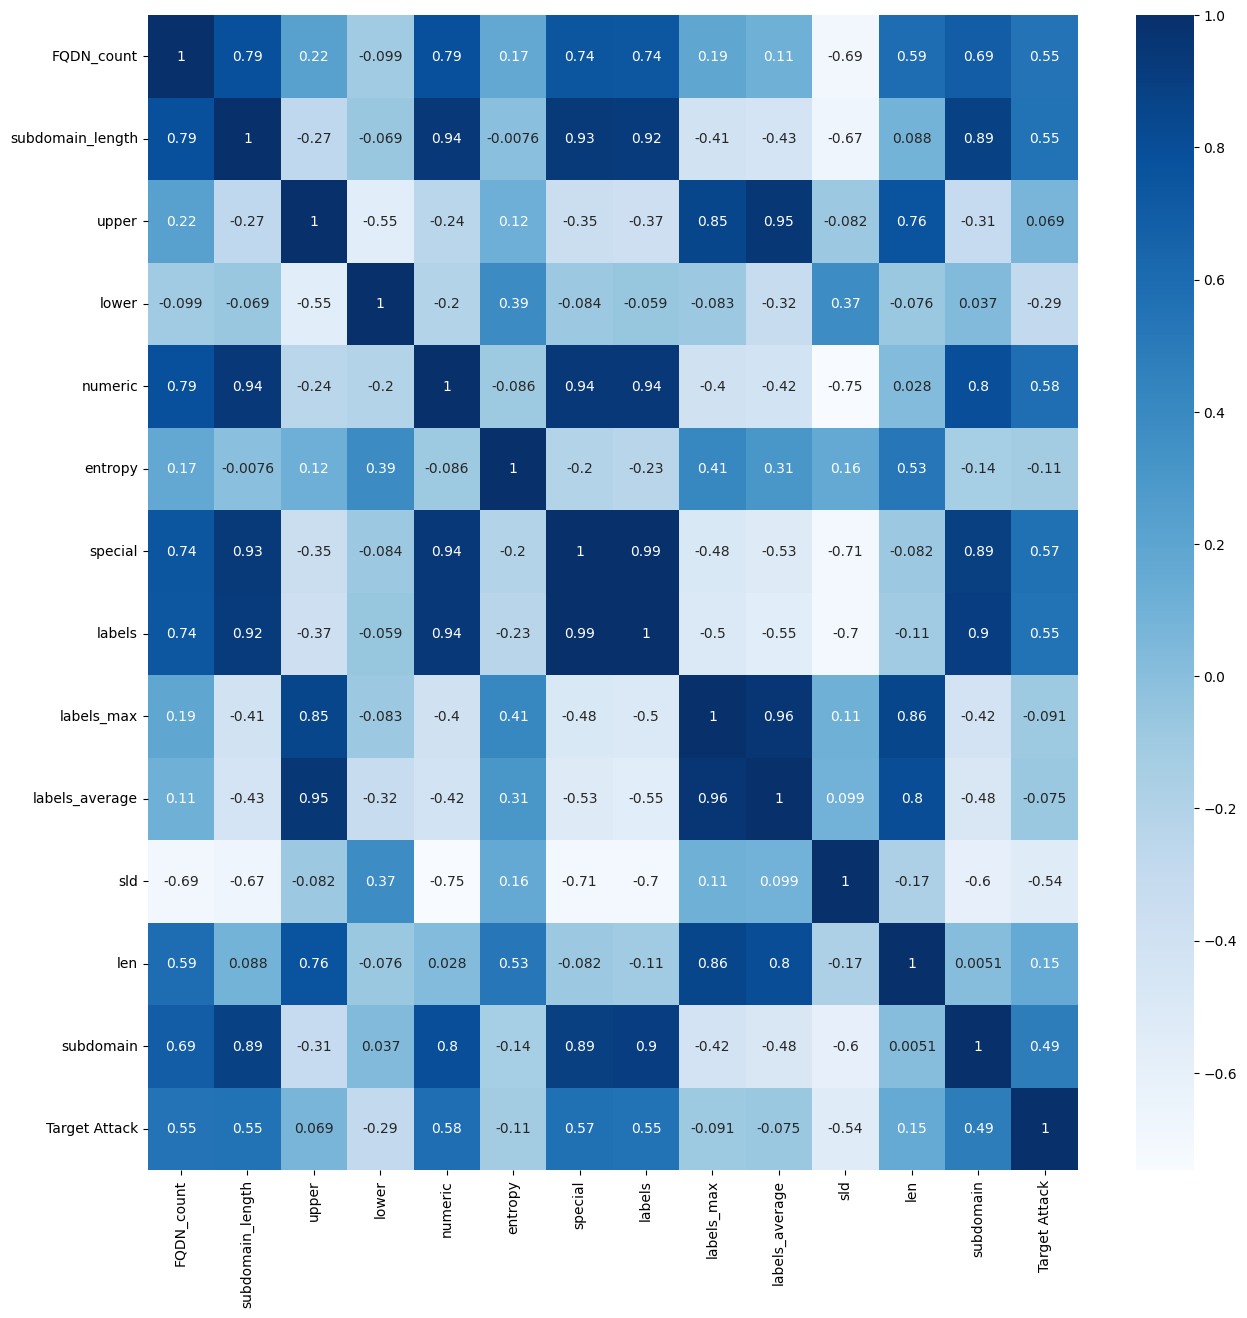

In [18]:
# plot correlation of each column with other
plt.figure(figsize=(15,15))
corelations = data.corr()
sns.heatmap(corelations, annot=True, cmap=plt.cm.Blues)
plt.show()

In [19]:
# droping feature which have correlation <= 0.5 with target variable
corelation = abs(corelations['Target Attack'])
columns = corelation[corelation > 0.5]
columns

FQDN_count          0.547279
subdomain_length    0.553668
numeric             0.581059
special             0.568947
labels              0.551868
sld                 0.536265
Target Attack       1.000000
Name: Target Attack, dtype: float64

#### Warpper Method
Using Recursive Feature Elimination

In [20]:
# splitting features and target variable
X = data[data.columns[:-1]]
y = data['Target Attack']

In [21]:
model = GradientBoostingClassifier()

In [22]:
# selecting 7 best features using recursuve feature elimination
cols = list(X.columns)
rfe = RFE(model, n_features_to_select=7)
X_rfe = rfe.fit_transform(X,y)
model.fit(X_rfe,y)  

temp = pd.Series(rfe.support_, index = cols) # gives a list of ture and false with columns names
columns= temp[temp==True].index.values
print(f"Featues that are selected: {columns}")

Featues that are selected: ['FQDN_count' 'subdomain_length' 'upper' 'lower' 'special' 'labels' 'sld']


#### Choosing Most Effective Features

In [23]:
# selecting only features which are best
columns = list(columns)
columns.append("Target Attack")
selected_data = data[columns]

In [24]:
selected_data.head()

,FQDN_count,subdomain_length,upper,lower,special,labels,sld,Target Attack
0,13,0,0,12,1,2,7160,0
1,25,8,0,10,6,6,83,0
2,8,0,0,6,2,2,3738,0
3,20,3,0,18,2,3,10690,0
4,27,10,0,10,6,6,83,1


In [25]:
# saving cleaned and selected features data
selected_data.to_csv("Kafka_clean_data.csv", header=True, index=False)

#### Spliting Data into Train and Test

In [26]:
X = selected_data[columns[:-1]].values
y = selected_data[columns[-1]].values

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

## Loading Models

In [9]:
xgb_static = joblib.load("static_model.pkl")
xgb_dynamic = joblib.load("static_model.pkl")

## Producer's Code

In [29]:
producer = KafkaProducer(bootstrap_servers=['localhost:9092'],
                         value_serializer=lambda x: 
                         dumps(x).encode('utf-8'))
if producer.bootstrap_connected():
    print(f"Successfully connected to bootstrap server")
else:
    print("Couldn't connect to bootstrap server.")

TOPIC_NAME = "ml-raw-dns"

Successfully connected to bootstrap server


In [30]:
def produce_message(producer_instance, topic, message):
    producer_instance.send(topic, message)
    producer_instance.flush()
    return

In [31]:
with open("Kafka_clean_data.csv") as f:
    start_time = datetime.now()
    for i, line in tqdm(enumerate(f)):
        #print(i, line)
        produce_message(producer_instance=producer, topic=TOPIC_NAME, message=line)
    end_time = datetime.now()
    print(f"Batch took {end_time-start_time} time for ingesting data")

print("Ingestion Completed")

268065it [15:22, 290.61it/s]

Batch took 0:15:22.419976 time for ingesting data
Ingestion Completed


## Consumer's Code

In [4]:
WS = 1000 #window size

In [10]:
consumer = KafkaConsumer(
    'ml-raw-dns',
    bootstrap_servers="localhost:9092",
    auto_offset_reset='earliest',
    enable_auto_commit=False,
    consumer_timeout_ms = 10000
)
next(consumer) #skips header

ConsumerRecord(topic='ml-raw-dns', partition=0, offset=0, timestamp=1668084755619, timestamp_type=0, key=None, value=b'"FQDN_count,subdomain_length,upper,lower,special,labels,sld,Target Attack\\n"', headers=[], checksum=None, serialized_key_size=-1, serialized_value_size=76, serialized_header_size=-1)

In [11]:
def check_dynamic_model(model, X, y):
    prediction = model.predict(X)
    return accuracy_score(y, prediction)

In [12]:
i = 1
results = []

window = []
for m in tqdm(consumer):
    temp = loads(m.value)[:-1].split(",")
    if 'FQDN_count' in temp:
        continue
    
    window.append(temp) # making a window of 10k
    
    if i % WS == 0:
        df = pd.DataFrame(window).astype(np.float32) # saving data into dataframe
        values = df.values # extracting numerical values
        X = values[:, :-1] # features
        y = values[:, -1] # target variables
        accuracy = check_dynamic_model(xgb_dynamic, X, y)
        results.append(accuracy) # saving accuracy of each window
        
        window.clear() # deleting previous data from window
    
    i += 1

1072259it [00:35, 30186.51it/s]


## Evaluating results

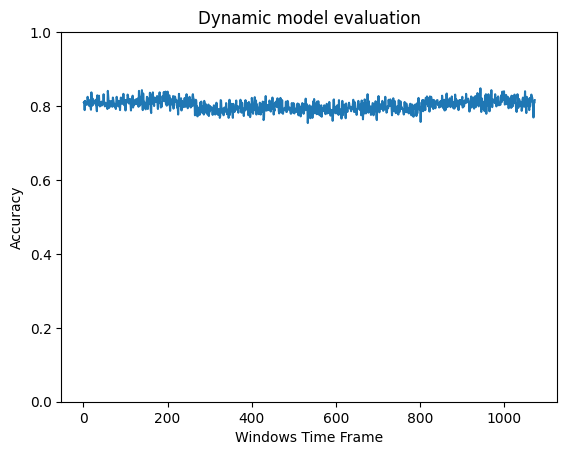

In [13]:
# plotting results of each window
plt.plot(np.arange(1, len(results)+1), results)
plt.xlabel("Windows Time Frame")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.title("Dynamic model evaluation")
plt.show()

## Final Results

For Training:  
As we can see that traditional models gives around 80 percent accuracy and dynamic model is also giving around 80 percent accuracy throughout all the time frame.
So, there is no need to train it further.

Which is Better?   
It depends where we are using this model. In real-time scenario, when data comes in the form of windows/packets on a network, it is better to use Dynamic model because we can not wait to get a whole data and then evaluate it.
While in offline scenario, where we have already all the data. We can use traditional mode because we can evaluate all data at once instead of windows.